MNIST is a standard image dataset used for handwritten digit classification. It contains grayscale images of digits from 0 to 9. Before training a CNN, it is important to inspect the dataset properly and apply preprocessing steps so the model can learn efficiently.

We need to:
- Load the MNIST dataset
- Check class distribution
- Check image dimensions
- Check pixel value range
- Identify preprocessing needs before CNN training
- Prepare final dataset for next step

In [2]:
!pip install tensorflow

  Using cached wheel-0.46.3-py3-none-any.whl.metadata (2.4 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 223.5/223.5 MB 6.8 MB/s  0:00:32m0:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.0/12.0 MB 12.1 MB/s  0:00:00 eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.8/2.8 MB 12.2 MB/s  0:00:00 eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 676.9/676.9 kB 14.7 MB/s  0:00:00
Using cached wheel-0.46.3-py3-none-any.whl (30 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 12.3 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 25.8/25.8 MB 12.0 MB/s  0:00:02 eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 17/17 [tensorflow]7 [tensorflow]

[notice] A new release of pip is available: 26.0 -> 26.0.1
[notice] To update, run: pip install --upgrade pip


In [3]:
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.datasets import mnist
from collections import Counter


(X_train, y_train), (X_test, y_test) = mnist.load_data()


print("Train Images Shape:", X_train.shape)
print("Train Labels Shape:", y_train.shape)
print("Test Images Shape :", X_test.shape)
print("Test Labels Shape :", y_test.shape)




11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step
Train Images Shape: (60000, 28, 28)
Train Labels Shape: (60000,)
Test Images Shape : (10000, 28, 28)
Test Labels Shape : (10000,)



Train Class Distribution:
Digit 0: 5923
Digit 1: 6742
Digit 2: 5958
Digit 3: 6131
Digit 4: 5842
Digit 5: 5421
Digit 6: 5918
Digit 7: 6265
Digit 8: 5851
Digit 9: 5949

Test Class Distribution:
Digit 0: 980
Digit 1: 1135
Digit 2: 1032
Digit 3: 1010
Digit 4: 982
Digit 5: 892
Digit 6: 958
Digit 7: 1028
Digit 8: 974
Digit 9: 1009

Single Image Shape: (28, 28)
Minimum Pixel Value: 0
Maximum Pixel Value: 255


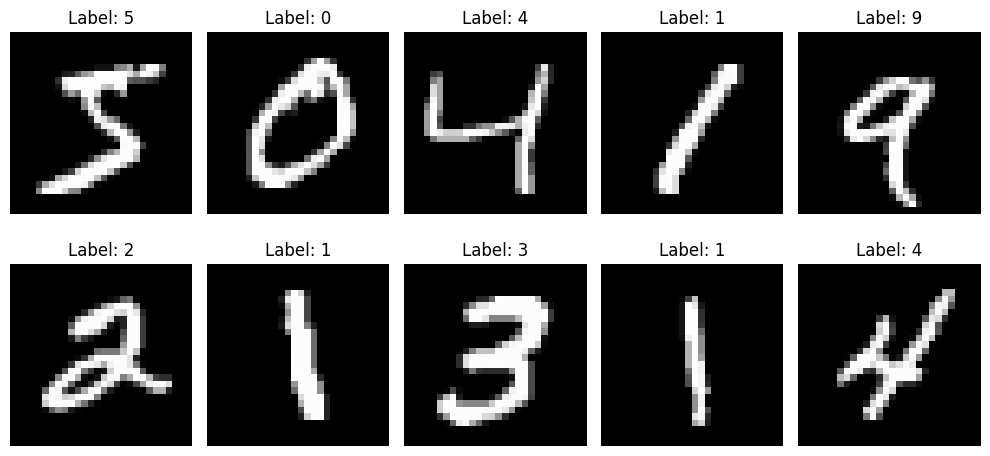


After Preprocessing:
Train Shape: (60000, 28, 28, 1)
Test Shape : (10000, 28, 28, 1)

Dataset is ready for CNN training.


In [4]:
train_counts = Counter(y_train)
test_counts = Counter(y_test)

print("\nTrain Class Distribution:")
for digit in sorted(train_counts.keys()):
    print(f"Digit {digit}: {train_counts[digit]}")

print("\nTest Class Distribution:")
for digit in sorted(test_counts.keys()):
    print(f"Digit {digit}: {test_counts[digit]}")


print("\nSingle Image Shape:", X_train[0].shape)


print("Minimum Pixel Value:", X_train.min())
print("Maximum Pixel Value:", X_train.max())


plt.figure(figsize=(10,5))
for i in range(10):
    plt.subplot(2,5,i+1)
    plt.imshow(X_train[i], cmap='gray')
    plt.title(f"Label: {y_train[i]}")
    plt.axis("off")
plt.tight_layout()
plt.show()


# Normalize pixel values (0-255 -> 0-1)
X_train = X_train.astype("float32") / 255.0
X_test = X_test.astype("float32") / 255.0

# Add channel dimension for CNN
X_train = np.expand_dims(X_train, axis=-1)
X_test = np.expand_dims(X_test, axis=-1)

print("\nAfter Preprocessing:")
print("Train Shape:", X_train.shape)
print("Test Shape :", X_test.shape)

# Final Ready Dataset
print("\nDataset is ready for CNN training.")

In this step, I built a Convolutional Neural Network (CNN) for handwritten digit classification using the MNIST dataset. CNN is suitable here because it can automatically learn useful image features such as edges, curves, and digit shapes.

The requirement says the model must contain at least two convolution layers, so I used two Conv2D layers followed by pooling and dense layers.

Architecture Used
- Conv Layer 1: 32 filters, size (3×3), ReLU
- MaxPooling: Reduce spatial size
- Conv Layer 2: 64 filters, size (3×3), ReLU
- MaxPooling: Further reduction
- Flatten: Convert feature maps into vector
- Dense Layer: 128 neurons, ReLU
- Output Layer: 10 neurons, Softmax

Why this design?
- Small filters (3×3) capture local patterns.
- More filters in deeper layers learn more complex shapes.
- Pooling reduces overfitting and computation.
- Dense layer combines extracted features for classification.

In [5]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras.datasets import mnist
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout

(X_train, y_train), (X_test, y_test) = mnist.load_data()


X_train = X_train.astype("float32") / 255.0
X_test = X_test.astype("float32") / 255.0


In [6]:
X_train = X_train.reshape(-1, 28, 28, 1)
X_test = X_test.reshape(-1, 28, 28, 1)


model = Sequential([
    Conv2D(32, (3,3), activation='relu', input_shape=(28,28,1), name='conv1'),
    MaxPooling2D((2,2)),
    
    Conv2D(64, (3,3), activation='relu', name='conv2'),
    MaxPooling2D((2,2)),
    
    Flatten(),
    Dense(128, activation='relu'),
    Dropout(0.3),
    Dense(10, activation='softmax')
])


model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)


/Users/omshinde/Desktop/Python/w2v_env/lib/python3.12/site-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1 (Conv2D)                  │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2 (Conv2D)                  │ (None, 11, 11, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 5, 5, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 1600)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       204,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 225,034 (879.04 KB)

 Trainable params: 225,034 (879.04 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/5
844/844 ━━━━━━━━━━━━━━━━━━━━ 7s 8ms/step - accuracy: 0.9369 - loss: 0.2084 - val_accuracy: 0.9847 - val_loss: 0.0534
Epoch 2/5
844/844 ━━━━━━━━━━━━━━━━━━━━ 6s 8ms/step - accuracy: 0.9797 - loss: 0.0656 - val_accuracy: 0.9888 - val_loss: 0.0376
Epoch 3/5
844/844 ━━━━━━━━━━━━━━━━━━━━ 6s 7ms/step - accuracy: 0.9849 - loss: 0.0473 - val_accuracy: 0.9905 - val_loss: 0.0336
Epoch 4/5
844/844 ━━━━━━━━━━━━━━━━━━━━ 6s 7ms/step - accuracy: 0.9886 - loss: 0.0371 - val_accuracy: 0.9913 - val_loss: 0.0326
Epoch 5/5
844/844 ━━━━━━━━━━━━━━━━━━━━ 6s 7ms/step - accuracy: 0.9905 - loss: 0.0303 - val_accuracy: 0.9915 - val_loss: 0.0285
Test Accuracy: 0.9901000261306763


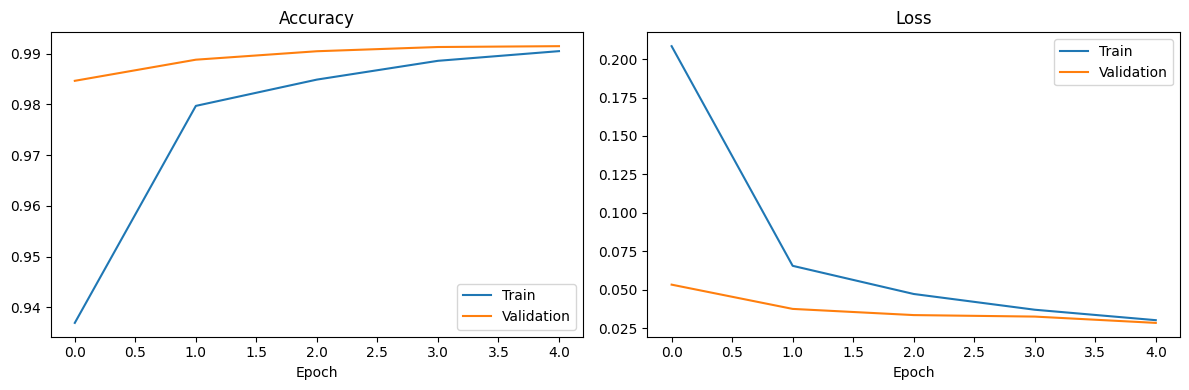

In [7]:
model.summary()

history = model.fit(
    X_train, y_train,
    validation_split=0.1,
    epochs=5,
    batch_size=64,
    verbose=1
)


test_loss, test_acc = model.evaluate(X_test, y_test, verbose=0)
print("Test Accuracy:", test_acc)


plt.figure(figsize=(12,4))

plt.subplot(1,2,1)
plt.plot(history.history['accuracy'], label='Train')
plt.plot(history.history['val_accuracy'], label='Validation')
plt.title("Accuracy")
plt.xlabel("Epoch")
plt.legend()

plt.subplot(1,2,2)
plt.plot(history.history['loss'], label='Train')
plt.plot(history.history['val_loss'], label='Validation')
plt.title("Loss")
plt.xlabel("Epoch")
plt.legend()

plt.tight_layout()
plt.show()

Filter shape: (3, 3, 1, 32)


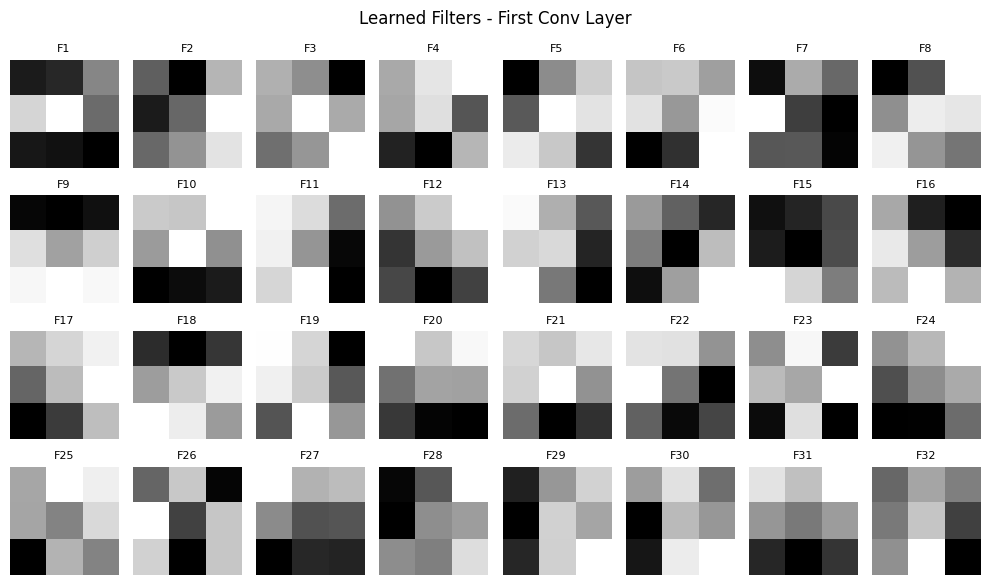

In [8]:
filters, biases = model.get_layer('conv1').get_weights()

print("Filter shape:", filters.shape)  


fig, axes = plt.subplots(4,8, figsize=(10,6))
axes = axes.flatten()

for i in range(32):
    f = filters[:, :, 0, i]
    axes[i].imshow(f, cmap='gray')
    axes[i].axis('off')
    axes[i].set_title(f"F{i+1}", fontsize=8)

plt.suptitle("Learned Filters - First Conv Layer")
plt.tight_layout()
plt.show()

This task is about representation learning. The main question is not just “can we train a model?”, but whether features learned from MNIST digits can transfer to a very different problem: social media post classification with imbalanced classes and mixed-language text.

MNIST contains clean handwritten digits. Social media data contains noisy language, slang, multiple scripts, emojis, short text, and class imbalance. So we should expect transfer to be challenging.